## **Assignment 5**

##### Submission Criteria

Based on the project objectives and the insights gained from the initial analysis, here are the key criteria for your submission:

1.  **Explore Gender vs. Spending Score:** Analyze the relationship between 'Gender' and 'Spending Score (1-100)' to see if gender plays a significant role in spending habits. Visualizations and summary statistics would be helpful here.
2.  **Apply Feature Engineering for Clustering:** Create a new feature using existing data (Feature Engineering). Then, explore if clustering can be effectively performed using this newly engineered feature in combination with one or more existing features. Document the feature engineering process, the chosen features for clustering, the determination of the optimal number of clusters (e.g., using the Elbow Method), and the resulting cluster visualization and interpretation.

#### Importing Libraries and Loading Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.cluster.hierarchy as sch

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Set plot style
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('data/Mall_Customers.csv')
print("Dataset loaded successfully.")
print(f"Data shape: {df.shape} \n")
df.head()

Dataset loaded successfully.
Data shape: (200, 5) 



,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### Exploratory Data Analysis

In [3]:
df.drop('CustomerID', axis=1, inplace=True)
print("CustomerID column dropped.")

CustomerID column dropped.


In [4]:
df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [5]:
df.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


##### 2.1) Distribution Analysis

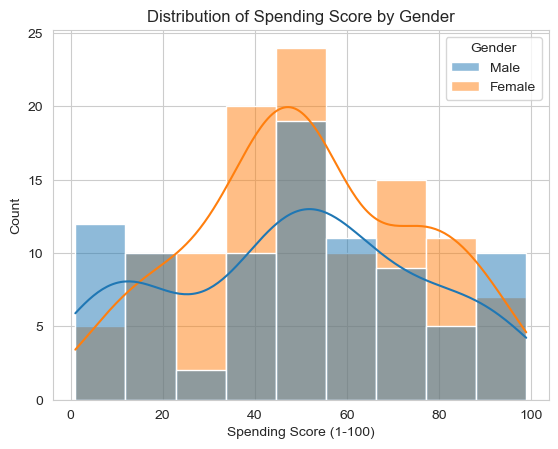

In [6]:
sns.histplot(data=df, x="Spending Score (1-100)", hue="Gender", kde=True).set_title("Distribution of Spending Score by Gender")
plt.show()

- Female Spends more than Male.
- Maximum number of Females have Spending Score between 35-60

##### 2.2) Comparative Visualization

<Axes: xlabel='Gender', ylabel='Spending Score (1-100)'>

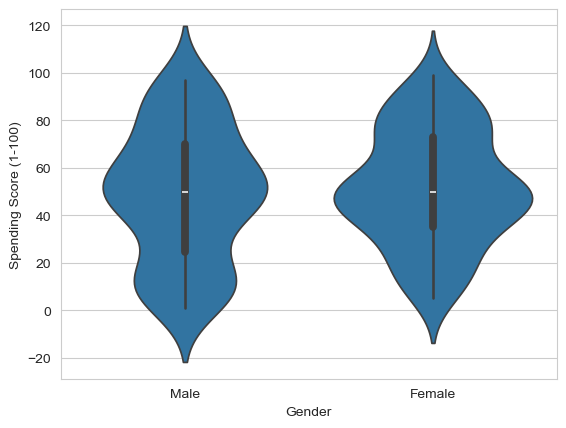

In [7]:
sns.violinplot(x="Gender", y="Spending Score (1-100)", data=df)

- Data is evenly distributed
- Median lies between 40-60

#### Feature Engineering

**Spending Efficiency**

This feature measures how much spending score a customer has relative to their income.

**Formula:**
$$\text{Spending Efficiency} = \frac{\text{Spending Score (1-100)}}{\text{Annual Income (k\$)}}$$

**Interpretation:**
*   **High Ratio:** High spender relative to income (Target for loyalty programs) [10].
*   **Low Ratio:** High income but low spender (Target for premium marketing) [3].

In [8]:
df["Spending_Efficiency"] = df["Spending Score (1-100)"] / df["Annual Income (k$)"]

#### Feature Scaling

In [9]:
X = df[["Annual Income (k$)", "Spending Score (1-100)", "Spending_Efficiency"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Determining Optimal Number of Clusters (Elbow Method)

d:\GeeksforGeeks 21 Projects-21_Days ML Deep Learning & GenAI\env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
d:\GeeksforGeeks 21 Projects-21_Days ML Deep Learning & GenAI\env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\GeeksforGeeks 21 Projects-21_Days ML Deep Learning & GenAI\env\Lib\site-packages\sklearn\cluster\_

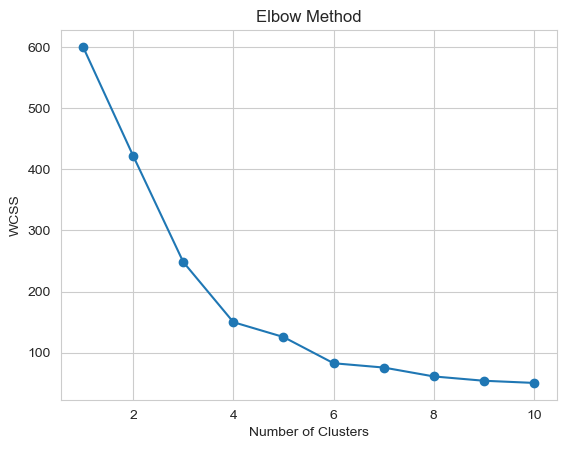

In [10]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

Optimal clusters = 4

In [11]:
# Apply K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

d:\GeeksforGeeks 21 Projects-21_Days ML Deep Learning & GenAI\env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


#### Cluster Visualization (2D Visualization)

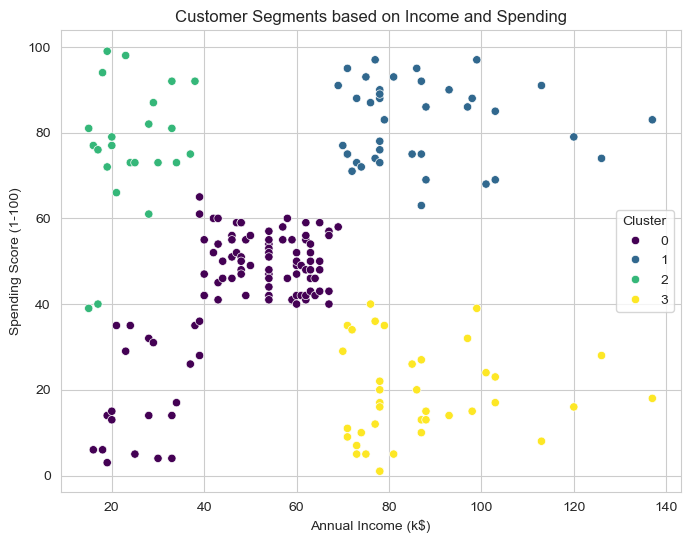

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="viridis"
)

plt.title("Customer Segments based on Income and Spending")
plt.show()

#### Cluster Interpretation

**Cluster 0 (Purple) – Average Customers**

* Income: Medium (~35k–65k)
* Spending Score: Medium (~40–60)

Business Strategy:

- Use loyalty programs
- Offer discount bundles to increase spending.

**Cluster 1 (Blue) – High Income, High Spending (Premium Customers)**

* Income: High (~70k–140k)
* Spending Score: High (~70–100)

Business Strategy:

- Target with premium products
- Offer VIP memberships
- Provide personalized marketing
- These are the most valuable customers.

**Cluster 2 (Green) – Low Income but High Spending**

* Income: Low (~15k–40k)
* Spending Score: High (~70–100)

Business Strategy:

- Promote offers, discounts, sales
- Use flash deals or coupons

**Cluster 3 (Yellow) – High Income but Low Spending**

* Income: High (~70k–140k)
* Spending Score: Low (~1–40)

Business Strategy:

- Use targeted marketing
- Offer premium product recommendations
- Provide exclusive deals